## OBJECTIVES : detail edible seaweed nutritional profiles

- Compile a robust dataset from the following ressources:
  -  CIQUAL database
  -  CEVA

observe **seaweed** nutritional profiles in comparison to other foods rich in PROTEIN, FIBRE, VITAMINS & MINERALS

## imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv
import os

load_dotenv(override=True) 



from lxml import etree # for importing other dataset that has 'alim_nom_fr' + 'ALIM_INDEX_FR' columns



In [2]:
#pd.set_option('display.max_rows', None)

### ciqual data english

In [3]:
CIQUAL_DATA = os.getenv("CIQUAL_DATA")


In [4]:
CIQUAL_DATA = os.getenv("CIQUAL_DATA")


df_ciqual = pd.read_excel(CIQUAL_DATA)


/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [5]:

df_ciqual.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,NaN,...,NaN,NaN,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,-,...,-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,-,...,"9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,-,...,-,-,"6,67","0,056","0,21","1,84","0,88","0,088","19,6","0,018"
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,-,...,-,-,10,"0,077","0,06","0,89","0,53","0,14",7,0


### ciqual data french

In [6]:
def load_xml_to_df(file_path):
    parser = etree.XMLParser(recover=True, encoding="windows-1252")
    tree = etree.parse(file_path, parser)
    root = tree.getroot()

    rows = []
    for alim in root:  # direct children: <ALIM>
        row = {child.tag: child.text for child in alim}
        rows.append(row)

    return pd.DataFrame(rows)

PATH_ALIM = os.getenv("PATH_ALIM")
PATH_COMPO = os.getenv("PATH_COMPO")
PATH_CONST = os.getenv("PATH_CONST")
PATH_ALIM_GRP = os.getenv("PATH_ALIM_GRP")
PATH_CEVA_DATA= os.getenv("CEVA_DATA")


df_alim = load_xml_to_df(PATH_ALIM)

df_alim.head()


,alim_code,alim_nom_fr,ALIM_NOM_INDEX_FR,alim_nom_eng,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code
0,1000,Pastis,Pastis,Pastis (anise-flavoured spirit),06,0603,060303
1,1001,Eau de vie,Eau de vie,Clear fruit brandy or eau-de-vie,06,0603,060303
2,1002,Gin,Gin,Gin,06,0603,060303
3,1003,Liqueur,Liqueur,Liqueur,06,0603,060303
4,1004,Rhum,Rhum,Rum,06,0603,060303


### CEVA data

In [53]:
# Path to Excel file with multiple sheets
ceva_data = "../data/CEVA_donnees_nutritionnelles_algues.xlsx"

# Read all sheets
xls = pd.ExcelFile(ceva_data)
df_list = []

for sheet in xls.sheet_names:
    df = pd.read_excel(ceva_data, sheet_name=sheet)
    # Keep only first 3 columns
    df = df.iloc[:, :3]
    df.columns = ["alim_nom_eng", "Nutrient", "Value"]  # Ensure consistent column names
    df_list.append(df)

# Combine all sheets into one dataframe
combined_df = pd.concat(df_list, ignore_index=True)

# Pivot so nutrients become columns
ceva_df = combined_df.pivot(index="alim_nom_eng", columns="Nutrient", values="Value").reset_index()

ceva_df.head()


Nutrient,alim_nom_eng,Beta-carotene (µg/100g),Calcium (mg/100g),Carbohydrate (g/100g),Chloride (mg/100g),Chrome (μg/100g),Copper (mg/100g),"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",FA mono (g/100g),FA poly (g/100g),FA saturated (g/100g),Fat (g/100g),Fibres (g/100g),Iodine (µg/100g),Iron (mg/100g),Magnesium (mg/100g),Manganese (mg/100g),Minéraux (g/100g),Molybdène (μg/100g),Phosphorus (mg/100g),Polyphénols (eq phloroglucinol),Potassium (mg/100g),"Protein, crude, N x 6.25 (g/100g)",Selenium (µg/100g),Sodium (mg/100g),Sugars (g/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B12 (µg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin C (mg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),VitamineA (eqrétinol) (mg/100g),VitamineB8ouHouBiotine (μg/100g),Water (g/100g),Zinc (mg/100g)
0,"Atlantic wakame (Alaria esculenta), dried or d...",9600,771,13.3,5825,209.9,0.3,843,202,0.23,0.85,0.31,1.5,42.9,362000,44.6,931,1.9,21.3,47.7,223,1,4310,12.2,25.4,3652,0.04,0.01,2,0.08,4,nd,0.1,429.2,65,nd,3.1,498.1,nd,nd,8.7,2.4
1,"Bladder wrack (Fucus vesiculosus), dehydrated",0,1256,14.9,nd,319.8,0.5,825,197,0.15,0.28,0.19,2.1,46.7,40500,13.1,872,11.7,20.7,43.1,100,5.9,3107,6.4,49.4,3477,nd,nd,nd,nd,nd,nd,nd,nd,42,nd,13,nd,nd,44.7,9.2,6.9
2,"Carragheen mosses (Chondrus crispus), dried or...",1500,911,15,4036,124.9,0.4,901,215,0.07,0.28,0.15,1.9,35.5,31300,18.1,1112,4.1,18.1,nd,159,0.34,2304,16.7,13,3289,0.4,0,1,0.1,2,nd,0.4,141.9,61.6,nd,3.5,153,0,nd,12.7,7
3,"Dulse (Palmaria palmata), dried or dehydrated",11000,577,20.8,8368,399.7,1,924,221,nd,nd,0.26,1.3,29.2,229000,29.3,264,9,24.3,41.6,250,0.4,7019,16.9,9.4,1873,0.02,0.2,4.6,0.3,3.6,0.4,0.2,295.3,46.9,0.9,4.1,467,0,11.7,7.6,4
4,"Gracilaria seaweeds (Gracilaria verrucosa), dr...",1900,770,23.4,5410,279.5,0.6,968,232,0.04,0.09,0.14,1.8,25.4,355800,36,420,32,21.6,144,221,0.19,4977,17.8,192.7,2856,nd,nd,nd,nd,nd,nd,nd,nd,27.2,nd,0.9,nd,nd,2.7,10,3.9


### Save ceva_df to a file

In [ ]:
ceva_df.to_csv('../data/processed/ceva_df.csv', index=False)


## Merge dataframes

### merge ciqual_english (ciqual) with ciqual_french (df_alim)

In [9]:
# Convert 'alim_code' to int for both dfs, to avoid error when merging
df_alim['alim_code'] = df_alim['alim_code'].astype(int)
df_ciqual['alim_code'] = df_ciqual['alim_code'].astype(int)
print(df_alim['alim_code'].dtype)
print(df_ciqual['alim_code'].dtype)

int64
int64


In [10]:
df_ciqual_eng_fr = pd.merge(
    df_ciqual,
    df_alim,
    on='alim_code',
)

print(df_ciqual_eng_fr.info(show_counts=True))
df_ciqual_eng_fr.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 82 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   alim_grp_code_x                                     3186 non-null   int64 
 1   alim_ssgrp_code_x                                   3186 non-null   int64 
 2   alim_ssssgrp_code_x                                 3186 non-null   int64 
 3   alim_grp_nom_eng                                    3141 non-null   object
 4   alim_ssgrp_nom_eng                                  3141 non-null   object
 5   alim_ssssgrp_nom_eng                                3141 non-null   object
 6   alim_code                                           3186 non-null   int64 
 7   alim_nom_eng_x                                      3186 non-null   object
 8   alim_nom_sci                                        270 non-null    object
 9   Energy, 

,alim_grp_code_x,alim_ssgrp_code_x,alim_ssssgrp_code_x,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng_x,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g),alim_nom_fr,ALIM_NOM_INDEX_FR,alim_nom_eng_y,alim_grp_code_y,alim_ssgrp_code_y,alim_ssssgrp_code_y
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,NaN,...,"0,4","0,056","30,8","0,21",Dessert (aliment moyen),Dessert,Desert (average),00,0000,000000
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,-,...,"< 0,16","0,29",31,"1,45","Salade de thon et légumes, appertisée",Salade de thon et légumes conserve,"Prepared mixed tuna and vegetable salad, canned",01,0101,000000
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,-,...,"0,2","0,12","11,1","1,23","Salade composée avec viande ou poisson, apper...",Salade composée avec viande ou poisson conserve,"Prepared mixed meat/fish canned, salad",01,0101,000000
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,-,...,"0,88","0,088","19,6","0,018","Champignons à la grecque, appertisés",Champignon sauce tomate conserve,"Greek-style marinated mushrooms, prepacked",01,0101,000000
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,-,...,"0,53","0,14",7,0,"Salade de pommes de terre, fait maison",Salade de pommes de terre,"Prepared potatoes salad, home-made",01,0101,000000


In [11]:
# drop duplicate columns
df_ciqual_eng_fr = df_ciqual_eng_fr.drop(columns=['alim_nom_eng_y', 'alim_grp_code_y', 'alim_ssgrp_code_y', 'alim_ssssgrp_code_y']).copy()

# rename columns and reorder columns for clarity
df_ciqual_eng_fr.rename(columns = {
    'alim_grp_code_x': 'alim_grp_code', 
    'alim_ssgrp_code_x': 'alim_ssgrp_code', 
    'alim_ssssgrp_code_x': 'alim_ssssgrp_code',
    'alim_nom_eng_x':  'alim_nom_eng'   
}, inplace=True)


### merge df_ciqual_eng_fr with CEVA

In [12]:
import unicodedata

# Utility: clean column names (strip leading/trainling spaces, normalize unicode)
def clean_columns(df):
    df = df.copy()
    df.columns = [
        unicodedata.normalize("NFC", col.strip()) for col in df.columns
    ]
    return df

# Clean both
df_ciqual_eng_fr = clean_columns(df_ciqual_eng_fr)
ceva_df   = clean_columns(ceva_df)

# Merge on alim_nom_eng, full outer join
df_merge = pd.merge(df_ciqual_eng_fr, ceva_df, on="alim_nom_eng", how="outer", suffixes=("_ciqual", "_ceva"))

nutrient_cols = [
    col.replace("_ciqual", "") for col in df_merge.columns
    if col.endswith("_ciqual") and col.replace("_ciqual", "_ceva") in df_merge.columns
]

# Handle nutrient columns
for col in nutrient_cols:
    ceva_col = f"{col}_ceva"
    ciqual_col = f"{col}_ciqual"
    
    df_merge[col] = df_merge[ceva_col].combine_first(df_merge[ciqual_col])
    df_merge.drop(columns=[ceva_col, ciqual_col], inplace=True)

# Handle metadata columns
# Detect all metadata columns in ciqual_df except 'alim_nom_eng'
metadata_cols = [col for col in df_ciqual_eng_fr.columns if col not in ["alim_nom_eng"]]

for col in metadata_cols:
    if f"{col}_ciqual" in df_merge.columns:
        # Just keep the CIQUAL version
        df_merge[col] = df_merge[f"{col}_ciqual"]
        df_merge.drop(columns=[f"{col}_ciqual"], inplace=True)
    
    # If CEVA had same-named metadata column, drop it
    if f"{col}_ceva" in df_merge.columns:
        df_merge.drop(columns=[f"{col}_ceva"], inplace=True)

# Cleaned, final result
df_merge = df_merge.sort_values("alim_nom_eng").reset_index(drop=True)

df_merge.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, N x Jones' factor, with fibres (kJ/100g)",...,Vitamin E (mg/100g),Vitamin K1 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
0,4.0,408.0,0.0,"meat, egg and fish","seafood, raw",-,10041.0,"Abalone or ormer or sea ear, raw",Strombus gigas,422,...,4,-,2,"0,15","0,19","1,5",3,"0,15",5,"0,73"
1,5.0,503.0,50303.0,milk and milk products,cheese and similar,semihard cheeses,12112.0,"Abondance cheese, from cow's milk",NaN,1640,...,"0,75","2,25","< 0,5","< 0,015","0,27","< 0,1","0,34","0,092","39,6","2,19"
2,2.0,204.0,20405.0,"fruits, vegetables, legumes and nuts",fruits,fruits from Martinique and their products,13404.0,"Acerola, pulp, raw, sampled in the island of L...",NaN,-,...,-,-,2850,-,-,-,-,-,-,-
3,10.0,1001.0,100101.0,miscellaneous,sauces,condiment sauces,11168.0,"Aioli sauce (garlic and olive oil mayonnaise),...",NaN,-,...,-,-,-,-,-,-,-,-,-,-
4,4.0,406.0,0.0,"meat, egg and fish","fish, raw",-,26006.0,"Alaska pollock, raw",Theragra chalcogramma,300,...,"0,36","0,1",traces,"0,07","0,07","1,1","< 0,16","0,14",3,"2,3"


### handle NaN values in alim_code, for seaweeds present in CEVA but not in ciqual

In [13]:
pd.set_option('display.max_column', None)

In [14]:
# identify seaweeds for which an alim_code must be attributed
df_merge.loc[df_merge['alim_code'].isna()]

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, N x Jones' factor, with fibres (kJ/100g)","Energy, N x Jones' factor, with fibres (kcal/100g)",Protein (g/100g),fructose (g/100g),galactose (g/100g),glucose (g/100g),lactose (g/100g),maltose (g/100g),sucrose (g/100g),Starch (g/100g),Polyols (g/100g),Ash (g/100g),Alcohol (g/100g),Organic acids (g/100g),FA 4:0 (g/100g),FA 6:0 (g/100g),FA 8:0 (g/100g),FA 10:0 (g/100g),FA 12:0 (g/100g),FA 14:0 (g/100g),FA 16:0 (g/100g),FA 18:0 (g/100g),FA 18:1 n-9 cis (g/100g),"FA 18:2 9c,12c (n-6) (g/100g)","FA 18:3 c9,c12,c15 (n-3) (g/100g)","FA 20:4 5c,8c,11c,14c (n-6) (g/100g)","FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",Cholesterol (mg/100g),Salt (g/100g),Potassium (mg/100g),Retinol (µg/100g),Vitamin K2 (µg/100g),alim_nom_fr,ALIM_NOM_INDEX_FR,Chrome (μg/100g),Minéraux (g/100g),Molybdène (μg/100g),Polyphénols (eq phloroglucinol),Potassium (mg/100g),VitamineA (eqrétinol) (mg/100g),VitamineB8ouHouBiotine (μg/100g),"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),"Protein, crude, N x 6.25 (g/100g)",Carbohydrate (g/100g),Fat (g/100g),Sugars (g/100g),Fibres (g/100g),FA saturated (g/100g),FA mono (g/100g),FA poly (g/100g),Calcium (mg/100g),Chloride (mg/100g),Copper (mg/100g),Iron (mg/100g),Iodine (µg/100g),Magnesium (mg/100g),Manganese (mg/100g),Phosphorus (mg/100g),Selenium (µg/100g),Sodium (mg/100g),Zinc (mg/100g),Beta-carotene (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Bladder wrack (Fucus vesiculosus), dehydrated",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,319.8,20.7,43.1,5.9,3107,nd,44.7,825,197,9.2,6.4,14.9,2.1,nd,46.7,0.19,0.15,0.28,1256,nd,0.5,13.1,40500,872,11.7,100,49.4,3477,6.9,0,nd,13,nd,42,nd,nd,nd,nd,nd,nd,nd
2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Toothed wrack (Fucus serratus), dehydrated",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.9,20.7,58.5,3.1,2654,nd,53.4,927,222,10.1,11.5,25.8,1.2,nd,30.8,nd,nd,nd,1187,nd,0.3,14.5,40500,661,14.3,88,10.8,3238,12,nd,nd,15,nd,nd,nd,nd,1.7,nd,nd,nd,nd


In [15]:
df_merge.loc[df_merge["alim_nom_eng"] == "Bladder wrack (Fucus vesiculosus), dehydrated", 
              ["alim_code", "alim_grp_code", "alim_ssgrp_code", "alim_grp_nom_eng", "alim_ssgrp_nom_eng", 'alim_nom_fr', 'ALIM_NOM_INDEX_FR']] = [99999, 10, 1007, "miscellaneous", "seaweed", 'Fucus vésiculeux (Fucus vesiculosus), séché ou déshydraté', 'Algue Fucus vésiculeux (Fucus vesiculosus), séché ou déshydraté']

df_merge.loc[df_merge["alim_nom_eng"] == "Toothed wrack (Fucus serratus), dehydrated", 
              ["alim_code", "alim_grp_code", "alim_ssgrp_code", "alim_grp_nom_eng", "alim_ssgrp_nom_eng", 'alim_nom_fr', 'ALIM_NOM_INDEX_FR']] = [99998, 10, 1007, "miscellaneous", "seaweed", 'Fucus vésiculeux (Fucus serratus), séché ou déshydraté', 'Algue Fucus vésiculeux (Fucus serratus), séché ou déshydraté']

# check transformations worked properly
df_merge.loc[df_merge['alim_code'].isna()]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, N x Jones' factor, with fibres (kJ/100g)","Energy, N x Jones' factor, with fibres (kcal/100g)",Protein (g/100g),fructose (g/100g),galactose (g/100g),glucose (g/100g),lactose (g/100g),maltose (g/100g),sucrose (g/100g),Starch (g/100g),Polyols (g/100g),Ash (g/100g),Alcohol (g/100g),Organic acids (g/100g),FA 4:0 (g/100g),FA 6:0 (g/100g),FA 8:0 (g/100g),FA 10:0 (g/100g),FA 12:0 (g/100g),FA 14:0 (g/100g),FA 16:0 (g/100g),FA 18:0 (g/100g),FA 18:1 n-9 cis (g/100g),"FA 18:2 9c,12c (n-6) (g/100g)","FA 18:3 c9,c12,c15 (n-3) (g/100g)","FA 20:4 5c,8c,11c,14c (n-6) (g/100g)","FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",Cholesterol (mg/100g),Salt (g/100g),Potassium (mg/100g),Retinol (µg/100g),Vitamin K2 (µg/100g),alim_nom_fr,ALIM_NOM_INDEX_FR,Chrome (μg/100g),Minéraux (g/100g),Molybdène (μg/100g),Polyphénols (eq phloroglucinol),Potassium (mg/100g),VitamineA (eqrétinol) (mg/100g),VitamineB8ouHouBiotine (μg/100g),"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),"Protein, crude, N x 6.25 (g/100g)",Carbohydrate (g/100g),Fat (g/100g),Sugars (g/100g),Fibres (g/100g),FA saturated (g/100g),FA mono (g/100g),FA poly (g/100g),Calcium (mg/100g),Chloride (mg/100g),Copper (mg/100g),Iron (mg/100g),Iodine (µg/100g),Magnesium (mg/100g),Manganese (mg/100g),Phosphorus (mg/100g),Selenium (µg/100g),Sodium (mg/100g),Zinc (mg/100g),Beta-carotene (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)


In [16]:
df_merge.loc[df_merge['alim_ssgrp_nom_eng'] == 'seaweed'].sort_values('alim_nom_eng')

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, N x Jones' factor, with fibres (kJ/100g)","Energy, N x Jones' factor, with fibres (kcal/100g)",Protein (g/100g),fructose (g/100g),galactose (g/100g),glucose (g/100g),lactose (g/100g),maltose (g/100g),sucrose (g/100g),Starch (g/100g),Polyols (g/100g),Ash (g/100g),Alcohol (g/100g),Organic acids (g/100g),FA 4:0 (g/100g),FA 6:0 (g/100g),FA 8:0 (g/100g),FA 10:0 (g/100g),FA 12:0 (g/100g),FA 14:0 (g/100g),FA 16:0 (g/100g),FA 18:0 (g/100g),FA 18:1 n-9 cis (g/100g),"FA 18:2 9c,12c (n-6) (g/100g)","FA 18:3 c9,c12,c15 (n-3) (g/100g)","FA 20:4 5c,8c,11c,14c (n-6) (g/100g)","FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",Cholesterol (mg/100g),Salt (g/100g),Potassium (mg/100g),Retinol (µg/100g),Vitamin K2 (µg/100g),alim_nom_fr,ALIM_NOM_INDEX_FR,Chrome (μg/100g),Minéraux (g/100g),Molybdène (μg/100g),Polyphénols (eq phloroglucinol),Potassium (mg/100g),VitamineA (eqrétinol) (mg/100g),VitamineB8ouHouBiotine (μg/100g),"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),"Protein, crude, N x 6.25 (g/100g)",Carbohydrate (g/100g),Fat (g/100g),Sugars (g/100g),Fibres (g/100g),FA saturated (g/100g),FA mono (g/100g),FA poly (g/100g),Calcium (mg/100g),Chloride (mg/100g),Copper (mg/100g),Iron (mg/100g),Iodine (µg/100g),Magnesium (mg/100g),Manganese (mg/100g),Phosphorus (mg/100g),Selenium (µg/100g),Sodium (mg/100g),Zinc (mg/100g),Beta-carotene (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
101,10.0,1007.0,0.0,miscellaneous,seaweed,-,20999.0,"Atlantic wakame (Alaria esculenta), dried or d...",NaN,769,187,"12,3",-,-,-,-,-,-,-,0,20,0,traces,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,"4,81",2180,-,-,"Wakamé atlantique (Alaria esculenta), séchée ...",Algue Wakamé,209.9,21.3,47.7,1,4310,nd,nd,843,202,8.7,12.2,13.3,1.5,0.04,42.9,0.31,0.23,0.85,771,5825,0.3,44.6,362000,931,1.9,223,25.4,3652,2.4,9600,nd,3.1,498.1,65,0.01,0.08,4,nd,0.1,429.2,2
268,10.0,1007.0,NaN,miscellaneous,seaweed,NaN,99999.0,"Bladder wrack (Fucus vesiculosus), dehydrated",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fucus vésiculeux (Fucus vesiculosus), séché ou...","Algue Fucus vésiculeux (Fucus vesiculosus), sé...",319.8,20.7,43.1,5.9,3107,nd,44.7,825,197,9.2,6.4,14.9,2.1,nd,46.7,0.19,0.15,0.28,1256,nd,0.5,13.1,40500,872,11.7,100,49.4,3477,6.9,0,nd,13,nd,42,nd,nd,nd,nd,nd,nd,nd
479,10.0,1007.0,0.0,miscellaneous,seaweed,-,20996.0,"Carragheen mosses (Chondrus crispus), dried or...",NaN,978,234,"16,6",-,-,-,-,-,-,-,0,"18,3",0,traces,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,"5,17",1570,-,-,Lichen de mer ou pioca ou goémon rouge (Chond...,Algue Lichen de mer,124.9,18.1,nd,0.34,2304,0,nd,901,215,12.7,16.7,15,1.9,0.4,35.5,0.15,0.07,0.28,911,4036,0.4,18.1,31300,1112,4.1,159,13,3289,7,1500,nd,3.5,153,61.6,0,0.1,2,nd,0.4,141.9,1
943,10.0,1007.0,0.0,miscellaneous,seaweed,-,20988.0,"Dulse (Palmaria palmata), dried or dehydrated",NaN,949,227,"17,2",-,-,-,-,-,-,-,0,"24,2",0,traces,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,"4,15",6810,-,-,"Dulse (Palmaria palmata), séchée ou déshydratée","Algue Dulse (Palmaria palmata), séchée ou dés...",399.7,24.3,41.6,0.4,7019,0,11.7,924,221,7.6,16.9,20.8,1.3,0.02,29.2,0.26,nd,nd,577,8368,1,29.3,229000,264,9,250,9.4,1873,4,11000,0.9,4.1,467,46.9,0.2,0.3,3.6,0.4,0.2,295.3,4.6
1258,10.0,1007.0,0.0,miscellaneous,seaweed,-,20993.0,"Gracilaria seaweeds (Gracilaria verrucosa), dr...",NaN,1010,243,"16,5",-,-,-,-,-,-,-,0,"17,8",0,traces,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,"7,8",5850,-,-,"Gracilaire ou ogonori (Gracilaria ve

In [17]:
df_merge.columns

Index(['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng', 'alim_nom_sci',
       'Energy, N x Jones' factor, with fibres (kJ/100g)',
       'Energy, N x Jones' factor, with fibres (kcal/100g)',
       'Protein (g/100g)', 'fructose (g/100g)', 'galactose (g/100g)',
       'glucose (g/100g)', 'lactose (g/100g)', 'maltose (g/100g)',
       'sucrose (g/100g)', 'Starch (g/100g)', 'Polyols (g/100g)',
       'Ash (g/100g)', 'Alcohol (g/100g)', 'Organic acids (g/100g)',
       'FA 4:0 (g/100g)', 'FA 6:0 (g/100g)', 'FA 8:0 (g/100g)',
       'FA 10:0 (g/100g)', 'FA 12:0 (g/100g)', 'FA 14:0 (g/100g)',
       'FA 16:0 (g/100g)', 'FA 18:0 (g/100g)', 'FA 18:1 n-9 cis (g/100g)',
       'FA 18:2 9c,12c (n-6) (g/100g)', 'FA 18:3 c9,c12,c15 (n-3) (g/100g)',
       'FA 20:4 5c,8c,11c,14c (n-6) (g/100g)',
       'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)',
       'FA 22:6 4c,7c,10c,13c,16c,

## Define columns to keep

### ID columns

In [18]:
ID_list = [
    'alim_code',
    'alim_grp_code',
    'alim_grp_nom_eng',
    "alim_ssgrp_nom_eng",
    "alim_nom_eng",
    "alim_nom_fr"
]

### Nutrient columns

In [19]:
nutrients_list = [
    "Energy, Regulation EU No 1169/2011 (kJ/100g)",
    "Energy, Regulation EU No 1169/2011 (kcal/100g)",
    "Water (g/100g)",
    "Fibres (g/100g)",
    "Protein, crude, N x 6.25 (g/100g)",
    "Carbohydrate (g/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Sugars (g/100g)",
    "Salt (g/100g)",
    "Sodium (mg/100g)",
    "Iron (mg/100g)",
    "Calcium (mg/100g)",
    "Magnesium (mg/100g)",
    'Phosphorus (mg/100g)',
    "Beta-carotene (µg/100g)",
    "Vitamin B1 or Thiamin (mg/100g)",
    "Vitamin B2 or Riboflavin (mg/100g)",
    "Vitamin B3 or Niacin (mg/100g)",
    #"Vitamin B5 or Pantothenic acid (mg/100g)",  # Don’t keep vitamin B5, because too many seaweeds with NaN for this nutrient
    "Vitamin B9 or Folate (µg/100g)",
    "Vitamin B12 (µg/100g)",
    "Vitamin C (mg/100g)",
    "Vitamin D (µg/100g)",
    "Vitamin E (mg/100g)",
    'Vitamin K1 (µg/100g)', 
    #’Vitamin K2 (µg/100g)',  # Don’t keep vitamin K2 as there is no value for any of the seaweeds, ciqual data is incomplete and ceva data doesn’t include vitamin K2
    "Zinc (mg/100g)",
    "Iodine (µg/100g)",
    #”Cholesterol (mg/100g)", # Don’t keep because insufficient data in df_ciqual, inexistent in ceva_df 
    #”FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)",  # Don’t keep because insufficient data in df_ciqual, inexistent in ceva_df 
    #”FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)" # Don’t keep because insufficient data in df_ciqual, inexistent in ceva_df 
    ]


In [20]:
df_merge_ordered = df_merge[ID_list+nutrients_list]

In [21]:
df_merge_ordered.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 33 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   alim_code                                       3188 non-null   float64
 1   alim_grp_code                                   3188 non-null   float64
 2   alim_grp_nom_eng                                3143 non-null   object 
 3   alim_ssgrp_nom_eng                              3143 non-null   object 
 4   alim_nom_eng                                    3188 non-null   object 
 5   alim_nom_fr                                     3188 non-null   object 
 6   Energy, Regulation EU No 1169/2011 (kJ/100g)    3171 non-null   object 
 7   Energy, Regulation EU No 1169/2011 (kcal/100g)  3171 non-null   object 
 8   Water (g/100g)                                  3185 non-null   object 
 9   Fibres (g/100g)                          

## Clean combined df

In [22]:
def clean_nutrient_dataframe(df, nutrient_columns, replacement_map=None, approx_multiplier=0.75, verbose=True):
    """
    Cleans and normalizes nutrient data from a DataFrame.

    Parameters:
    - df (pd.DataFrame): The input DataFrame to clean.
    - nutrient_columns (list): List of column names to clean.
    - replacement_map (dict, optional): Custom replacements for values like 'traces', '-', etc.
    - approx_multiplier (float, optional): Multiplier to apply to values marked as approximations (e.g., "< 0.1").
    - verbose (bool): If True, prints non-numeric warnings and NaN summary.

    Returns:
    - df_cleaned (pd.DataFrame): Cleaned DataFrame with float values and approximation tracking.
    """
    # Default replacements if none provided
    if replacement_map is None:
        replacement_map = {
            "traces": "0.000001",
            "-": np.nan,
            "nan": np.nan,
            "NaN": np.nan,
            "NAN": np.nan,
            "None": np.nan,
            "": np.nan,
            "[nan]": np.nan,
            "n/a": np.nan,
            "nd": np.nan
        }

    # Deep copy to avoid modifying original
    df_cleaned = df.copy()

    # Initialize approximation mask
    approx_mask = pd.DataFrame(False, index=df_cleaned.index, columns=nutrient_columns)

    for col in nutrient_columns:
        # Convert to string and strip whitespace
        col_str = df_cleaned[col].astype(str).str.strip()

        # Detect and mark approximations
        is_approx = col_str.str.startswith("< ")
        approx_mask[col] = is_approx

        # Clean approximation values
        col_str.loc[is_approx] = (
            col_str.loc[is_approx]
            .str.replace("< ", "", regex=False)
            .str.replace(",", ".", regex=False)
        )

        # Apply replacements
        col_str = col_str.replace(replacement_map, regex=False).astype(str)

        # Normalize decimal commas
        col_str = col_str.str.replace(",", ".", regex=False)


        # Coerce to numeric and log problematic values
        coerced = col_str[~col_str.isna() & pd.to_numeric(col_str, errors='coerce').isna()]
        if verbose and not coerced.empty:
            print(f" Coerced to NaN in '{col}': {coerced.unique()}")

        # Convert to float
        df_cleaned[col] = pd.to_numeric(col_str, errors='coerce')

        # Step 7: Apply approximation multiplier
        df_cleaned.loc[is_approx, col] *= approx_multiplier

    # Step 8: Ensure float type
    df_cleaned[nutrient_columns] = df_cleaned[nutrient_columns].astype(float)

    # Step 9: Add count of approximated values per row
    df_cleaned["approx_count"] = approx_mask.sum(axis=1)

    # Step 10: Final NaN check
    if verbose:
        print("\nNaN count after cleaning:")
        print(df_cleaned[nutrient_columns].isna().sum())

        print("\nApproximation counts per column:")
        print(approx_mask.sum())

    return df_cleaned


In [23]:
df_combined_clean = clean_nutrient_dataframe(df_merge_ordered, nutrients_list, replacement_map=None, approx_multiplier=0.75, verbose=True)

 Coerced to NaN in 'Energy, Regulation EU No 1169/2011 (kJ/100g)': ['nan']
 Coerced to NaN in 'Energy, Regulation EU No 1169/2011 (kcal/100g)': ['nan']
 Coerced to NaN in 'Water (g/100g)': ['nan']
 Coerced to NaN in 'Fibres (g/100g)': ['nan']
 Coerced to NaN in 'Protein, crude, N x 6.25 (g/100g)': ['nan']
 Coerced to NaN in 'Carbohydrate (g/100g)': ['nan']
 Coerced to NaN in 'Fat (g/100g)': ['nan']
 Coerced to NaN in 'FA saturated (g/100g)': ['nan']
 Coerced to NaN in 'Sugars (g/100g)': ['nan']
 Coerced to NaN in 'Salt (g/100g)': ['nan']
 Coerced to NaN in 'Sodium (mg/100g)': ['nan']
 Coerced to NaN in 'Iron (mg/100g)': ['nan']
 Coerced to NaN in 'Calcium (mg/100g)': ['nan']
 Coerced to NaN in 'Magnesium (mg/100g)': ['nan']
 Coerced to NaN in 'Phosphorus (mg/100g)': ['nan']
 Coerced to NaN in 'Beta-carotene (µg/100g)': ['nan']
 Coerced to NaN in 'Vitamin B1 or Thiamin (mg/100g)': ['nan']
 Coerced to NaN in 'Vitamin B2 or Riboflavin (mg/100g)': ['nan']
 Coerced to NaN in 'Vitamin B3 or 

In [24]:
df_combined_clean.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   alim_code                                       3188 non-null   float64
 1   alim_grp_code                                   3188 non-null   float64
 2   alim_grp_nom_eng                                3143 non-null   object 
 3   alim_ssgrp_nom_eng                              3143 non-null   object 
 4   alim_nom_eng                                    3188 non-null   object 
 5   alim_nom_fr                                     3188 non-null   object 
 6   Energy, Regulation EU No 1169/2011 (kJ/100g)    2300 non-null   float64
 7   Energy, Regulation EU No 1169/2011 (kcal/100g)  2300 non-null   float64
 8   Water (g/100g)                                  2829 non-null   float64
 9   Fibres (g/100g)                          

### Add "seaweed_type" column for graphs

In [25]:
df_combined_clean = df_combined_clean.copy()

# function to add a new column with more details about seaweed subgroup
def categorize_seaweed(name):
    name = name.lower()
    if "spirulina" in name:
        return "microalgae"
    elif any(term in name for term in ["agar", "porphyra", "dulse", "gracilaria", "chondrus"]):
        return "algue rouge"
    elif any(term in name for term in ["ulva", "enteromorpha", "sea lettuce"]):
        return "algue verte"
    elif any(term in name for term in [
        "wakame", "undaria", "saccharina", "kelp", "kombu", "laminaria",
        "himanthalia", "fucus", "ascophyllum", "alaria"
    ]):
        return "algue brune"
    else:
        return "unknown"
    

df_combined_clean["seaweed_type"] = df_combined_clean["alim_nom_eng"].apply(categorize_seaweed)

df_combined_clean.head()

,alim_code,alim_grp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_nom_eng,alim_nom_fr,"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),Fibres (g/100g),"Protein, crude, N x 6.25 (g/100g)",Carbohydrate (g/100g),Fat (g/100g),FA saturated (g/100g),Sugars (g/100g),Salt (g/100g),Sodium (mg/100g),Iron (mg/100g),Calcium (mg/100g),Magnesium (mg/100g),Phosphorus (mg/100g),Beta-carotene (µg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Zinc (mg/100g),Iodine (µg/100g),approx_count,seaweed_type
0,10041.0,4.0,"meat, egg and fish","seafood, raw","Abalone or ormer or sea ear, raw","Ormeau, cru",422.0,99.6,74.6,0.0000,14.40,8.690000,0.830,0.150,0.00,0.47,189.0,5.90,31.0,48.0,154.0,0.0,0.15000,0.19,1.500,5.0,0.73,2.000000,0.0000,4.00,NaN,0.82,NaN,0,unknown
1,12112.0,5.0,milk and milk products,cheese and similar,"Abondance cheese, from cow's milk",Abondance,1630.0,393.0,37.2,0.0000,26.60,0.000001,31.600,20.100,0.15,1.73,690.0,0.09,760.0,28.0,570.0,149.0,0.01125,0.27,0.075,39.6,2.19,0.375000,0.1875,0.75,2.25,3.50,15.0,6,unknown
2,13404.0,2.0,"fruits, vegetables, legumes and nuts",fruits,"Acerola, pulp, raw, sampled in the island of L...","Cerise acérola, pulpe, crue, prélevée à la Ma...",NaN,NaN,93.1,NaN,0.56,NaN,0.097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850.000000,NaN,NaN,NaN,NaN,NaN,0,unknown
3,11168.0,10.0,miscellaneous,sauces,"Aioli sauce (garlic and olive oil mayonnaise),...","Sauce aïoli, préemballée",NaN,NaN,NaN,0.4200,1.13,4.700000,41.000,NaN,3.14,1.85,736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,unknown
4,26006.0,4.0,"meat, egg and fish","fish, raw","Alaska pollock, raw","Lieu ou colin d'Alaska, cru",300.0,70.8,81.2,0.1275,16.30,0.000001,0.610,0.015,0.00,0.48,190.0,0.40,12.8,36.9,160.0,0.0,0.07000,0.07,1.100,3.0,2.30,0.000001,1.1000,0.36,0.10,0.41,78.2,1,unknown


In [26]:
df_combined_clean['seaweed_name_Eng'] = (
    df_combined_clean['alim_nom_eng']
    .str.replace(", dried or dehydrated", "", regex=False)
)

df_combined_clean['seaweed_name_French'] = (
    df_combined_clean['alim_nom_fr']
    .str.replace(", séchée ou déshydratée", "", regex=False)
    .str.replace(", séché ou déshydraté", "", regex=False)
)

In [27]:
df_combined_clean.loc[df_combined_clean['alim_ssgrp_nom_eng'] == 'seaweed']


,alim_code,alim_grp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_nom_eng,alim_nom_fr,"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),Fibres (g/100g),"Protein, crude, N x 6.25 (g/100g)",Carbohydrate (g/100g),Fat (g/100g),FA saturated (g/100g),Sugars (g/100g),Salt (g/100g),Sodium (mg/100g),Iron (mg/100g),Calcium (mg/100g),Magnesium (mg/100g),Phosphorus (mg/100g),Beta-carotene (µg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Zinc (mg/100g),Iodine (µg/100g),approx_count,seaweed_type,seaweed_name_Eng,seaweed_name_French
101,20999.0,10.0,miscellaneous,seaweed,"Atlantic wakame (Alaria esculenta), dried or d...","Wakamé atlantique (Alaria esculenta), séchée ...",843.0,202.0,8.70,42.9,12.20,13.30,1.50,0.310,0.04,4.810,3652.0,44.60,771.0,931.0,223.0,9600.0,0.010,0.080,4.000,429.20,2.0,65.00,NaN,3.10,498.1,2.40,362000.0,0,algue brune,Atlantic wakame (Alaria esculenta),Wakamé atlantique (Alaria esculenta)
268,99999.0,10.0,miscellaneous,seaweed,"Bladder wrack (Fucus vesiculosus), dehydrated","Fucus vésiculeux (Fucus vesiculosus), séché ou...",825.0,197.0,9.20,46.7,6.40,14.90,2.10,0.190,NaN,NaN,3477.0,13.10,1256.0,872.0,100.0,0.0,NaN,NaN,NaN,NaN,NaN,42.00,NaN,13.00,NaN,6.90,40500.0,0,algue brune,"Bladder wrack (Fucus vesiculosus), dehydrated",Fucus vésiculeux (Fucus vesiculosus)
479,20996.0,10.0,miscellaneous,seaweed,"Carragheen mosses (Chondrus crispus), dried or...",Lichen de mer ou pioca ou goémon rouge (Chond...,901.0,215.0,12.70,35.5,16.70,15.00,1.90,0.150,0.40,5.170,3289.0,18.10,911.0,1112.0,159.0,1500.0,0.000,0.100,2.000,141.90,1.0,61.60,NaN,3.50,153.0,7.00,31300.0,0,algue rouge,Carragheen mosses (Chondrus crispus),Lichen de mer ou pioca ou goémon rouge (Chond...
943,20988.0,10.0,miscellaneous,seaweed,"Dulse (Palmaria palmata), dried or dehydrated","Dulse (Palmaria palmata), séchée ou déshydratée",924.0,221.0,7.60,29.2,16.90,20.80,1.30,0.260,0.02,4.150,1873.0,29.30,577.0,264.0,250.0,11000.0,0.200,0.300,3.600,295.30,4.6,46.90,0.90,4.10,467.0,4.00,229000.0,0,algue rouge,Dulse (Palmaria palmata),Dulse (Palmaria palmata)
1258,20993.0,10.0,miscellaneous,seaweed,"Gracilaria seaweeds (Gracilaria verrucosa), dr...","Gracilaire ou ogonori (Gracilaria verrucosa),...",968.0,232.0,10.00,25.4,17.80,23.40,1.80,0.140,NaN,7.800,2856.0,36.00,770.0,420.0,221.0,1900.0,NaN,NaN,NaN,NaN,NaN,27.20,NaN,0.90,NaN,3.90,355800.0,0,algue rouge,Gracilaria seaweeds (Gracilaria verrucosa),Gracilaire ou ogonori (Gracilaria verrucosa)
1431,20990.0,10.0,miscellaneous,seaweed,"Kombu or Japanese kelp (Laminaria japonica), d...","Kombu ou kombu japonais (Laminaria japonica),...",929.0,222.0,11.40,34.1,7.90,24.90,2.60,0.720,NaN,6.410,2448.0,13.00,811.0,1030.0,654.0,2000.0,0.200,0.400,1.500,124.00,NaN,14.77,0.00,NaN,NaN,1.20,232800.0,0,algue brune,Kombu or Japanese kelp (Laminaria japonica),Kombu ou kombu japonais (Laminaria japonica)
1472,20987.0,10.0,miscellaneous,seaweed,"Laver (Porphyra sp.), dried or dehydrated","Nori (Porphyra sp.), séchée ou déshydratée",1075.0,257.0,6.70,36.8,30.20,11.70,1.80,0.500,0.00,4.960,1900.0,36.40,440.0,480.0,491.0,18000.0,0.500,1.800,6.300,31.80,27.2,63.90,0.60,3.10,225.0,4.30,5600.0,0,algue rouge,Laver (Porphyra sp.),Nori (Porphyra sp.)
1849,20998.0,10.0,miscellaneous,seaweed,"North Atlantic rockweed (Ascophyllum nodosum),...",Ascophylle noueux ou goémon noir (Ascophyllum...,863.0,207.0,10.70,43.6,7.40,16.30,2.70,0.110,NaN,7.150,2871.0,19.30,1601.0,831.0,94.0,3800.0,0.300,0.700,1.900,22.68,NaN,89.40,1.00,14.00,1018.0,6.00,68600.0,0,algue brune,North Atlantic rockweed (Ascophyllum nodosum),Ascophylle noueux ou goémon noir (Ascophyllum...
2516,20986.0,10.0,miscellaneous,seaweed,"Sea belt (Saccharina latissima), dried or dehy...","Kombu royal (Saccharina latissima), séchée ou...",856.0,205

## Save to csv for reuse

In [56]:

df_combined_clean.to_csv('../data/df_ciqual_ceva_seaweeds_cleaned', index=False)

# PCA with reduced nutrients and foods lists

## Define different food lists

In [29]:
df_combined_clean = df_combined_clean.rename(columns={
    'Protein, crude, N x 6.25 (g/100g)': 'Protein (g/100g)'
})


In [30]:
# Trimmed down nutrients for public-friendly comparison
nutrients_list_step1 = [
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Calcium (mg/100g)",
    "Iodine (µg/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Iron (mg/100g)"
]




### food_selection_animal_protein

List of animal-based PROTEIN-rich foods in database to compare their nutritional with profiles with seaweeds. These are animal-based protein-rich foods that are commonly consumed in France.

In [31]:
food_selection_animal_protein = {
    # Beef
    6100: "Beef, rib steak, lean, grilled/pan-fried",
    6110: "Beef, sirloin steak, grilled/pan-fried",
    6200: "Beef steak, grilled",
    6253: "Beef, minced steak, 10% fat, cooked",
    
   # 1581: "Viande des Grisons (processed/cured)",

    # Chicken
    36018: "Chicken, breast, without skin, cooked",
    36006: "Chicken leg, meat, roasted/baked",
    36004: "Chicken wing, meat and skin, roasted/baked",
    66004: "Chicken, leg, meat and skin, roasted/baked",
    36041: "Chicken, breast, without skin, cooked, organic",

    # Turkey
    36318: "Milanese-style turkey escalope or breaded veal",

    # Fish & seafood
    25996: "Salmon, cooked (average)",
    25997: "Cod, cooked (average)",
    26087: "Mackerel, smoked",
    26034: "Sardine, in oil, canned, drained",
    26181: "Yellowfin tuna, canned in brine, drained",
    8292: "Seafood terrine, with/without fish, prepacked (mixed seafood)",

    # Other meats (veal, pork, lamb, duck, rabbit)
    36318:  "Milanese-style turkey escalope or breaded veal escalope",
    21524:  "Lamb, chop, grilled (average)",
    28101:  "Pork, chop, grilled",
    36205:  "Duck, magret, cooked in pan",
    34002:  "Rabbit, meat, cooked",

    # Eggs
    22014: "Egg, soft-boiled",
    22010: "Egg, hard-boiled"
    
}

#### reverse food lookup

In [32]:
# Reverse the dictionary to use food names as keys
food_names = list(food_selection_animal_protein.values())

# Function to get alim_code for each food name
def get_alim_codes_from_names(df, food_names):
    code_lookup = {}
    for name in food_names:
        match = df[df['alim_nom_fr'] == name]
        if not match.empty:
            code_lookup[name] = match['alim_code'].values[0]
        else:
            code_lookup[name] = 'Not found'
    return code_lookup

# Run the lookup
corrected_codes = get_alim_codes_from_names(df_combined_clean, food_names)

reversed_dict = {code: name for name, code in corrected_codes.items()}

not_found = {name: code for name, code in corrected_codes.items() if code == 'Not found'}

reversed_dict


{'Not found': 'Egg, hard-boiled'}

### Seaweed list

In [33]:
seaweed_list = [
    #brown
    20999, # Atlantic wakame (Alaria esculenta)
    99999, # Bladder wrack (Fucus vesiculosus), dehydrated
    20990, # Kombu or Japanese kelp
    20998, # North Atlantic rockweed (Ascophyllum nodosum)
    20986, # Sea belt (Saccharina latissima)
    20992, # Sea thong (Himanthalia elongata)
    20991, # Tangle (Laminaria digitata), dried or dehydrated
    99998, # Toothed wrack (Fucus serratus)
    20994, # Toothed wrack or bladder wrack (Fucus serratus)
    20984, # Wakame (Undaria pinnatifida)

    #red 
    20988, # Dulse (Palmaria palmata)
    20987, # Laver (Porphyra sp.)
    20996, # Carragheen mosses (Chondrus crispus)
    20993, # Gracilaria seaweeds (Gracilaria verrucosa)

    #green
    20995, # Sea lettuce (Enteromorpha sp.), dried or dehyd...
    20985, # Sea lettuce (ulva sp.), dried or dehydrated)
]


### food_selection_plant_protein

List of plant-based foods that are rich in protein and are also in database. This list will be used to compare these foods' nutritional profiles to those of the edible seaweeds in the database. These are animal-based protein-rich foods that are commonly consumed in France.

In [34]:

food_selection_plant_protein = {
    # Legumes
    20833: 'Pigeon pea, whole, steamed',
    20587: 'Lentil, green, boiled/cooked in water',
    20588: 'Lentil, blond, boiled/cooked in water',
    20589: 'Lentil, pink or red, boiled/cooked in water',
    20502: 'Haricot bean, boiled/cooked in water',
    20503: 'Red kidney bean, boiled/cooked in water',
    20513: 'Flageolet bean, boiled/cooked in water',
    20506: 'Split pea, boiled/cooked in water',
    20507: 'Chick pea, boiled/cooked in water',
    20901: 'Soybean, whole grain',

    # Nuts & seeds
    15002: 'Peanut, grilled, salted',
    15004: 'Hazelnut',
    15005: 'Walnut, dried, husked',
    15008: 'Brazil nut',
    15047: 'Seeds, chia, dried',
    15054: 'Cashew nut, grilled, unsalted',
    15042: 'Almond, grilled, salted',
    15052: 'Flaxseed, brown',

    # Nut/seed paste
    15202: 'Peanut butter or peanut paste',
    15203: 'Tahini (sesame paste)',

    # Plant-based meat substitutes
    20917: 'Tempeh',
    25592: 'Plant-based burger or steak from wheat (seitan) and vegetables',
    25591: 'Plant-based burger or steak from lentil, soybean and vegetables'}

### food_selection_plant_fibre

List of plant-based foods that are rich in FIBRE. This list will be used to compare these foods' nutritional profiles to those of the edible seaweeds in the database. These are animal-based fibre-rich foods that are commonly consumed in France.

In [35]:
food_selection_plant_fibre = {
    # Vegetables
    20000: 'Artichoke, globe, cooked',
    20067: 'Artichoke, canned, drained',
    20006: 'Broccoli, cooked',
    20013: 'Brussels sprout, cooked',
    20009: 'Carrot, raw',

    # Fruits
    13001: 'Apricot, pitted, dried',
    13013: 'Fig, dried',

    # Grains & Bread
    7110: 'Bread, wholemeal or integral bread (made with flour type 150)',
    7111: 'Sandwich loaf, wholemeal',
    7420: 'Wheat swedish toast, wholemeal'
 }



### food_selection_plant_minerals_vitamins

List of plant-based herbs and spices that are rich in MINERALS and are also in database. This list will be used to compare these foods' nutritional profiles to those of the edible seaweeds in the database. These are plant-based herbs and spices that are commonly consumed in France.

In [36]:
food_selection_plant_minerals_vitamins = {
    11014: "Parsley, fresh",
    11024: "Parsley, dried",
    3083: "Coriander, fresh",
    11033: "Basil, fresh",
    11032: "Basil, dried",
    11089: "Turmeric, powder",
    11049: "Paprika",
    11070: "Thyme, fresh",
    11035: "Oregano, dried",
    11068: "Rosemary, fresh",
    11027: "Mint, fresh",
    11029: "Mint, dried",
    11069: "Sage, fresh",
    11037: "Sage, dried",
    11093: "Dill, fresh",
    11074: "Ginger, raw",
    11006: "Ginger, powder",
}

In [37]:
df_combined_clean.loc[df_combined_clean['alim_nom_fr'].str.contains('entrecôte', case=False, na=False)]

,alim_code,alim_grp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_nom_eng,alim_nom_fr,"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),Fibres (g/100g),Protein (g/100g),Carbohydrate (g/100g),Fat (g/100g),FA saturated (g/100g),Sugars (g/100g),Salt (g/100g),Sodium (mg/100g),Iron (mg/100g),Calcium (mg/100g),Magnesium (mg/100g),Phosphorus (mg/100g),Beta-carotene (µg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g),Vitamin C (mg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Zinc (mg/100g),Iodine (µg/100g),approx_count,seaweed_type,seaweed_name_Eng,seaweed_name_French
178,6100.0,4.0,"meat, egg and fish",cooked meat,"Beef, rib steak, lean, grilled/pan-fried","Boeuf, entrecôte, partie maigre, grillée/poêlée",829.0,198.0,62.3,0.0,25.5,0.075000,10.70,4.75,0.0,0.150,58.0,2.55,12.00,23.0,200.0,0.0,0.070,0.15,4.40,6.0,1.85,0.0,0.10,0.58,1.6,6.34,6.0,1,unknown,"Beef, rib steak, lean, grilled/pan-fried","Boeuf, entrecôte, partie maigre, grillée/poêlée"
179,6103.0,4.0,"meat, egg and fish",raw meat,"Beef, rib steak, raw","Boeuf, entrecôte, crue",961.0,231.0,62.5,0.0,19.4,0.000000,17.10,8.07,0.0,0.075,29.8,2.21,5.44,19.5,154.0,0.0,0.069,0.20,3.91,4.0,1.85,0.0,0.45,0.66,1.5,4.25,1.1,0,unknown,"Beef, rib steak, raw","Boeuf, entrecôte, crue"
1356,6908.0,4.0,"meat, egg and fish",cooked meat,"Horse, rib steak, grilled/pan-fried","Cheval, entrecôte, grillée/poêlée",711.0,169.0,64.4,0.0,28.2,0.000001,6.24,1.99,NaN,NaN,NaN,3.38,NaN,NaN,NaN,NaN,NaN,NaN,5.55,NaN,1.44,NaN,NaN,NaN,NaN,3.18,NaN,0,unknown,"Horse, rib steak, grilled/pan-fried","Cheval, entrecôte, grillée/poêlée"
1357,6905.0,4.0,"meat, egg and fish",raw meat,"Horse, rib steak, raw","Cheval, entrecôte, crue",499.0,118.0,NaN,0.0,22.1,0.000001,3.34,1.08,NaN,NaN,NaN,2.84,NaN,NaN,NaN,NaN,NaN,NaN,6.15,NaN,1.44,NaN,NaN,NaN,NaN,2.51,NaN,0,unknown,"Horse, rib steak, raw","Cheval, entrecôte, crue"


### Prepare the data & keep the missing-value mask

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Keep original with NaNs
df_pca_original = df_combined_clean[
    ['alim_code', 'alim_nom_eng', 'alim_ssgrp_nom_eng', 
     'seaweed_type', 'alim_nom_fr', 'seaweed_name_Eng', 
     'seaweed_name_French'] 
     + nutrients_list_step1
]

# Create mask of missing nutrient values
nan_mask = df_pca_original[nutrients_list_step1].isna().any(axis=1)

# Fill NaNs (for PCA only)
df_pca_filled = df_pca_original.copy()
df_pca_filled[nutrients_list_step1] = df_pca_filled[nutrients_list_step1].fillna(0)


In [39]:
df_pca_original.head(20)

,alim_code,alim_nom_eng,alim_ssgrp_nom_eng,seaweed_type,alim_nom_fr,seaweed_name_Eng,seaweed_name_French,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iodine (µg/100g),Fat (g/100g),FA saturated (g/100g),Iron (mg/100g)
0,10041.0,"Abalone or ormer or sea ear, raw","seafood, raw",unknown,"Ormeau, cru","Abalone or ormer or sea ear, raw","Ormeau, cru",0.0000,14.40,31.00,NaN,0.830,0.150,5.90
1,12112.0,"Abondance cheese, from cow's milk",cheese and similar,unknown,Abondance,"Abondance cheese, from cow's milk",Abondance,0.0000,26.60,760.00,15.0,31.600,20.100,0.09
2,13404.0,"Acerola, pulp, raw, sampled in the island of L...",fruits,unknown,"Cerise acérola, pulpe, crue, prélevée à la Ma...","Acerola, pulp, raw, sampled in the island of L...","Cerise acérola, pulpe, crue, prélevée à la Ma...",NaN,0.56,NaN,NaN,0.097,NaN,NaN
3,11168.0,"Aioli sauce (garlic and olive oil mayonnaise),...",sauces,unknown,"Sauce aïoli, préemballée","Aioli sauce (garlic and olive oil mayonnaise),...","Sauce aïoli, préemballée",0.4200,1.13,NaN,NaN,41.000,NaN,NaN
4,26006.0,"Alaska pollock, raw","fish, raw",unknown,"Lieu ou colin d'Alaska, cru","Alaska pollock, raw","Lieu ou colin d'Alaska, cru",0.1275,16.30,12.80,78.2,0.610,0.015,0.40
5,26152.0,"Alaska pollock, smoked","fish, cooked",unknown,"Lieu ou colin d'Alaska, fumé","Alaska pollock, smoked","Lieu ou colin d'Alaska, fumé",0.0000,18.30,NaN,NaN,0.900,0.100,NaN
6,26179.0,"Albacore, in olive oil, canned, drained",fish products,unknown,"Thon germon ou thon blanc, à l'huile d'olive,...","Albacore, in olive oil, canned, drained","Thon germon ou thon blanc, à l'huile d'olive,...",0.0000,31.30,1.00,6.0,6.950,1.410,0.50
7,26076.0,"Albacore, raw","fish, raw",unknown,"Thon germon ou thon blanc, cru","Albacore, raw","Thon germon ou thon blanc, cru",0.0000,27.20,3.50,14.0,1.370,0.260,0.95
8,26077.0,"Albacore, steamed under pressure",fish products,unknown,"Thon germon ou thon blanc, cuit à la vapeur s...","Albacore, steamed under pressure","Thon germon ou thon blanc, cuit à la vapeur s...",0.0000,30.00,1.33,40.0,5.060,1.350,1.01
9,15032.0,"Alfalfa seeds, raw",nuts and seeds,unknown,"Luzerne, graine","Alfalfa seeds, raw","Luzerne, graine",7.9000,35.00,136.00,NaN,12.600,NaN,12.90


### Run PCA & save results as dfs

In [40]:


# Standardize numeric values
X_scaled = StandardScaler().fit_transform(df_pca_filled[nutrients_list_step1])

# Run PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# Create results DataFrame
pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['alim_code'] = df_pca_filled['alim_code']
pca_df['alim_nom_eng'] = df_pca_filled['alim_nom_eng']
pca_df['alim_nom_fr'] = df_pca_filled['alim_nom_fr']
pca_df['seaweed_group'] = df_pca_filled['alim_ssgrp_nom_eng'].str.lower() == 'seaweed'
pca_df['seaweed_type'] = df_pca_filled['seaweed_type']
pca_df['seaweed_name_Eng'] = df_pca_filled['seaweed_name_Eng']
pca_df['seaweed_name_French'] = df_pca_filled['seaweed_name_French']

pca_df['has_missing'] = nan_mask  # True if any nutrient was missing


### Set seaweed_type index lists

In [41]:


id_list_brown_seaweed = [20999, 99999, 20990, 20998, 20986, 20992, 20991, 99998, 20984]
id_list_red_seaweed = [20988, 20987, 20993, 20996]
id_list_green_seaweed = [20995, 20985]

## New Interactive PCAs

#### SEAWEEDS    VS.     PROTEIN-rich, FIBRE-rich, VITAMIN & MINERAL-rich foods

- PCA of ALL Foods
- highlighting SEAWEEDS (brown, red, green), Protein-rich foods (animal and plants + seaweeds) & Fibre-rich foods
- see legend for hightlight colors

In [42]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['animal_protein'] = pca_df['alim_code'].isin(food_selection_animal_protein.keys())
pca_df['plant_protein']  = pca_df['alim_code'].isin(food_selection_plant_protein.keys())
pca_df['plant_protein']  = pca_df['alim_code'].isin(food_selection_plant_protein.keys())
pca_df['plant_fibre'] = pca_df['alim_code'].isin(food_selection_plant_fibre.keys())
pca_df['plant_min_vit'] = pca_df['alim_code'].isin(food_selection_plant_minerals_vitamins.keys())


pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

# Combine all group labels into a single column for color
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Aliment riche en protéines végétales'
    elif row['animal_protein']:
        return 'Aliment riche en protéines animales'
    elif row['plant_fibre']:
        return 'Aliment riche en fibres'
    elif row['plant_min_vit']:
        return 'Aliment riche en minéraux ou vitamines'
    else:
        return 'Autres aliments'

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'saddlebrown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Aliment riche en protéines végétales': 'darkviolet',
    'Aliment riche en protéines animales': 'blue',
    'Aliment riche en protéines fibre': 'purple',
    'Aliment riche en minéraux ou vitamines': 'orange',
    'Autres aliments': 'lightgrey'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    category_orders={    # add order to how names appear in legend
    'Aliment groupe': [
        'Algue brune',
        'Algue rouge',
        'Algue verte',
        'Aliment riche en protéines végétales',
        'Aliment riche en protéines animales',
        'Aliment riche en fibres',
        'Aliment riche en minéraux ou vitamines',
        'Autres aliments'
        ]
    },
    color_discrete_map=color_map,
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Algues vs aliments riches en protéines, fibres, minéraux et vitamines"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df['Aliment groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Aliment riche en protéines végétales', 'Aliment riche en protéines animales', 'Aliment riche en fibres', 'Aliment riche en minéraux ou vitamines']:
        marker_sizes.append(12)
    else:
        marker_sizes.append(8)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_overall_seaweed_vs_proteins-fibre-mineral-vitamin-rich-foods.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


### PCA ALL Foods - highlight of Protein-rich foods (animal & plants) vs. seaweeds

- PCA of ALL Foods
- highlighting SEAWEEDS (brown, red, green), Protein-rich foods (animal and plants)
- see legend for hightlight colors

In [43]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['animal_protein'] = pca_df['alim_code'].isin(food_selection_animal_protein.keys())
pca_df['plant_protein']  = pca_df['alim_code'].isin(food_selection_plant_protein.keys())


pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

# Combine all group labels into a single column for color
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Aliment riche en protéines végétales'
    elif row['animal_protein']:
        return 'Aliment riche en protéines animales'
    else:
        return 'Autres aliments'

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'saddlebrown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Aliment riche en protéines végétales': 'darkviolet',
    'Aliment riche en protéines animales': 'blue',
    'Autres aliments': 'lightgrey'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    color_discrete_map=color_map,
    category_orders={    # add order to how names appear in legend
    'Aliment groupe': [
        'Algue brune',
        'Algue rouge',
        'Algue verte',
        'Aliment riche en protéines végétales',
        'Aliment riche en protéines animales',
        'Autres aliments'
        ]
    },    
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Algues vs aliments riches en protéines"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df['Aliment groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Aliment riche en protéines végétales', 'Aliment riche en protéines animales']:
        marker_sizes.append(12)
    else:
        marker_sizes.append(8)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_overall_seaweed_vs_proteins.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### PCA Protein-rich foods (animal and plants + seaweeds)

- PCA of PROTEIN-rich foods ONLY
- highlighting SEAWEEDS (brown, red, green), Protein-rich foods (animal and plants + seaweeds)
- see legend for hightlight colors

In [44]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist (use alim_code instead of index)
pca_df['animal_protein'] = pca_df['alim_code'].isin(food_selection_animal_protein.keys())
pca_df['plant_protein']  = pca_df['alim_code'].isin(food_selection_plant_protein.keys())
pca_df['brown_seaweed']  = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']    = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed']  = pca_df['alim_code'].isin(id_list_green_seaweed)

# Assign groups ("Autres aliments" excluded here)
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Aliment riche en protéines végétales'
    elif row['animal_protein']:
        return 'Aliment riche en protéines animales'
    else:
        return None  # exclude later

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Keep only rows that belong to a defined group
pca_df_filtered = pca_df[pd.notnull(pca_df['Aliment groupe'])].copy()

# Color map
color_map = {
    'Algue brune': 'brown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Aliment riche en protéines végétales': 'darkviolet',
    'Aliment riche en protéines animales': 'blue'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df_filtered,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    color_discrete_map=color_map,
    hover_name='seaweed_name_French',
    labels={'seaweed_name_French': 'Aliment'},
    title="Analyse en Composantes Principales (ACP) : comparaison des algues avec d'autres aliments riches en protéines"
)

fig.update_layout(width=1200, height=900)

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df_filtered['Aliment groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(12)
    elif g in ['Aliment riche en protéines végétales', 'Aliment riche en protéines animales']:
        marker_sizes.append(12)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML
fig.write_html("pca_seaweed_vs_protein-rich_foods.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### PCA ALL Foods - highlight of FIBRE-rich foods (animal) vs. seaweeds

- PCA of ALL Foods
- highlighting SEAWEEDS (brown, red, green), Protein-rich foods (animal and plants + seaweeds) & Fibre-rich foods
- see legend for hightlight colors

In [45]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['plant_fibre'] = pca_df['alim_code'].isin(food_selection_plant_fibre.keys())

pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

# Combine all group labels into a single column for color
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_fibre']:
        return 'Fibres végétales'
    else:
        return 'Autres aliments'

pca_df['groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'brown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Fibres végétales': 'orange',
    'Autres aliments': 'lightgrey'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='groupe',
    color_discrete_map=color_map,
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Focus aliments riches en fibres"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and fibres
marker_sizes = []
for g in pca_df['groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Fibres végétales']:
        marker_sizes.append(12)
    else:
        marker_sizes.append(8)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_overall_seaweed_vs_fibres.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### PCA Fibre-rich foods (plants + seaweeds)

- PCA of FIBRE-rich foods ONLY
- highlighting SEAWEEDS (brown, red, green), FIBRE-rich foods (plants) + seaweeds
- see legend for hightlight colors

In [46]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist (use alim_code instead of index)
pca_df['plant_fibre'] = pca_df['alim_code'].isin(food_selection_plant_fibre.keys())
pca_df['brown_seaweed']  = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']    = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed']  = pca_df['alim_code'].isin(id_list_green_seaweed)

# Assign groups ("Autres aliments" excluded here)
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_fibre']:
        return 'Fibres végétales'
    else:
        return None  # exclude later

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Keep only rows that belong to a defined group
pca_df_filtered = pca_df[pd.notnull(pca_df['Aliment groupe'])].copy()

# Color map
color_map = {
    'Algue brune': 'brown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Fibres végétales': 'orange'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df_filtered,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    color_discrete_map=color_map,
    hover_name='seaweed_name_French',
    labels={'seaweed_name_French': 'Aliment'},
    title="Analyse en Composantes Principales (ACP) : comparaison des algues avec d'autres aliments riches en fibres"
)

fig.update_layout(width=1200, height=900)

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df_filtered['Aliment groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(12)
    elif g in ['Fibres végétales']:
        marker_sizes.append(12)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML
fig.write_html("pca_seaweed_vs_fibres.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



/opt/anaconda3/lib/python3.11/site-packages/matplotlib/collections.py:1109: UserWarning:

Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.



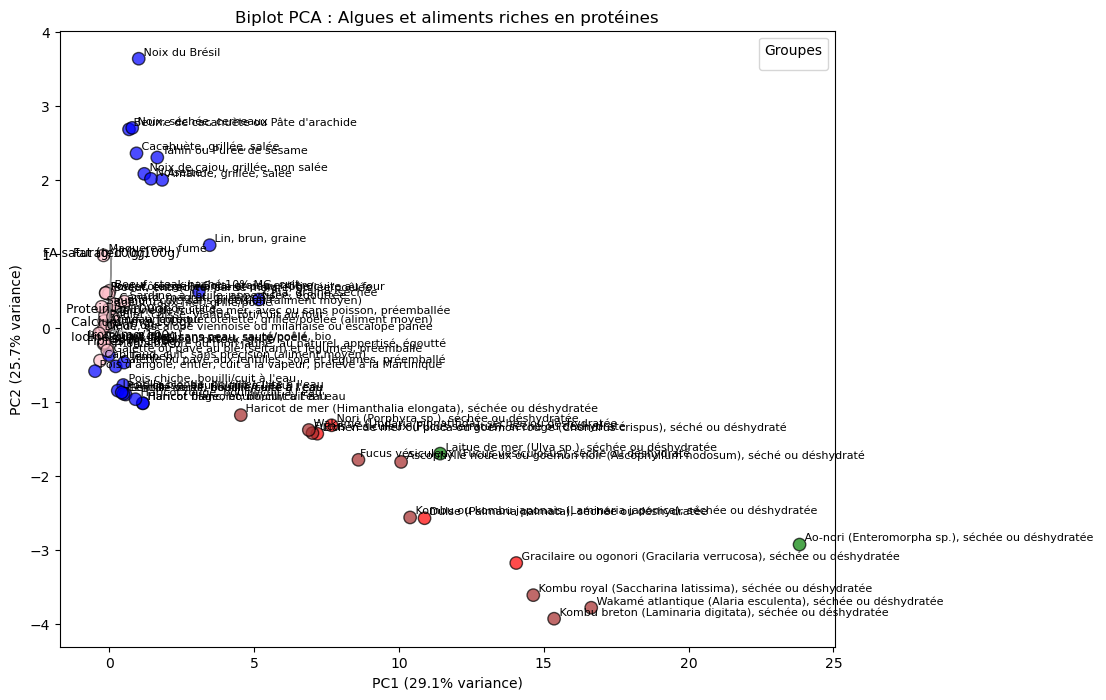

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ensure 'groupe' has proper labels ---
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Protéines végétales'
    elif row['animal_protein']:
        return 'Protéines animales'
    else:
        return None   # we will drop these later

pca_df['groupe'] = pca_df.apply(assign_group, axis=1)

# --- Keep only seaweeds & protein-rich foods ---
pca_df_plot = pca_df[pca_df['groupe'].notna()]

# --- Define color map for groups ---
color_map = {
    'Algue brune': 'brown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Protéines végétales': 'blue',
    'Protéines animales': 'pink'
}

# --- Plot foods (points) ---
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    pca_df_plot['PC1'],
    pca_df_plot['PC2'],
    c=pca_df_plot['groupe'].map(color_map),
    alpha=0.7,
    s=80,
    edgecolor='k'
)

# --- Add labels for foods (optional, can be noisy) ---
for i, row in pca_df_plot.iterrows():
    ax.text(row['PC1']+0.05, row['PC2']+0.05, row['alim_nom_fr'], fontsize=8)

# --- Add nutrient vectors (loadings) ---
nutrients = nutrients_list_step1
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, nutrient in enumerate(nutrients):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             color='grey', alpha=0.6, head_width=0.02)
    ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, nutrient,
            color='black', ha='center', va='center', fontsize=9)

# --- Axis labels with explained variance ---
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Biplot PCA : Algues et aliments riches en protéines")

# --- Legend ---
handles, labels = scatter.legend_elements()
ax.legend(handles, pca_df_plot['groupe'].unique(), title="Groupes")

plt.show()


### fibre-rich

In [48]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['plant_fibre'] = pca_df['alim_code'].isin(food_selection_plant_fibre.keys())

pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_fibre']:
        return 'Fibres végétales'
    else:
        return None  # exclude later
    
pca_df['groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'brown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Fibres végétales': 'orange',
    'Autres aliments': 'lightgrey'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='groupe',
    color_discrete_map=color_map,
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Algues vs aliments végétales riches en fibres"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df['groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Protéines végétales', 'Protéines animales']:
        marker_sizes.append(12)
    else:
        marker_sizes.append(8)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_seaweed_vs_fibre_rich.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### PCA ALL Foods - highlight of MINERAL & VITAMIN-rich foods (plants) vs. seaweeds

- PCA of ALL Foods
- highlighting SEAWEEDS (brown, red, green), MINERAL & VITAMIN-rich foods (plants)
- see legend for hightlight colors

In [49]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['plant_min_vit'] = pca_df['alim_code'].isin(food_selection_plant_minerals_vitamins.keys())

pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

# Combine all group labels into a single column for color
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Aliment riche en minéraux ou en vitamines'
    else:
        return 'Autres aliments'

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'saddlebrown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Aliment riche en minéraux ou en vitamines': 'orange',
    'Autres aliments': 'lightgrey'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    color_discrete_map=color_map,
    category_orders={    # add order to how names appear in legend
    'Aliment groupe': [
        'Algue brune',
        'Algue rouge',
        'Algue verte',
        'Aliment riche en minéraux ou en vitamines',
        'Autres aliments'
        ]
    },    
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Algues vs aliments riches en protéines"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df['groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Aliment riche en minéraux ou en vitamines']:
        marker_sizes.append(12)
    else:
        marker_sizes.append(8)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_overall_seaweed_vs_mineraux_vitamines.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### PCA MINERAL AND/OR VITAMN-rich foods (plants) vs. seaweeds

- PCA of MINERAL AND/OR VITAMIN-rich foods ONLY
- highlighting SEAWEEDS (brown, red, green), MINERAL & VITAMIN-rich foods (plants)
- see legend for hightlight colors

In [50]:
import plotly.express as px
import pandas as pd

# Ensure boolean masks exist
pca_df['plant_min_vit'] = pca_df['alim_code'].isin(food_selection_plant_minerals_vitamins.keys())

pca_df['brown_seaweed'] = pca_df['alim_code'].isin(id_list_brown_seaweed)
pca_df['red_seaweed']   = pca_df['alim_code'].isin(id_list_red_seaweed)
pca_df['green_seaweed'] = pca_df['alim_code'].isin(id_list_green_seaweed)

# Combine all group labels into a single column for color
def assign_group(row):
    if row['brown_seaweed']:
        return 'Algue brune'
    elif row['red_seaweed']:
        return 'Algue rouge'
    elif row['green_seaweed']:
        return 'Algue verte'
    elif row['plant_protein']:
        return 'Aliment riche en minéraux ou en vitamines'
    else:
        return None

pca_df['Aliment groupe'] = pca_df.apply(assign_group, axis=1)

# Color map
color_map = {
    'Algue brune': 'saddlebrown',
    'Algue rouge': 'red',
    'Algue verte': 'green',
    'Aliment riche en minéraux ou en vitamines': 'orange'
}

# Create interactive PCA plot
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Aliment groupe',
    color_discrete_map=color_map,
    category_orders={    # add order to how names appear in legend
    'Aliment groupe': [
        'Algue brune',
        'Algue rouge',
        'Algue verte',
        'Aliment riche en minéraux ou en vitamines',
        ]
    },    
    hover_name='seaweed_name_French',  # column name from df to use for food name on hover
    labels={'seaweed_name_French': 'Aliment'},  # change name of column as it appears when hovering
    title="Analyse en Composantes Principales (ACP) des aliments : Algues vs aliments riches en minéraux ou en vitamines"
)

fig.update_layout(width=1200, height=900) # make plot bigger

# Make markers bigger for seaweeds and proteins
marker_sizes = []
for g in pca_df['Aliment groupe']:
    if g in ['Algue brune', 'Algue rouge', 'Algue verte']:
        marker_sizes.append(15)
    elif g in ['Aliment riche en minéraux ou en vitamines']:
        marker_sizes.append(12)

fig.update_traces(marker=dict(size=marker_sizes, line=dict(width=1, color='DarkSlateGrey')))

# Show interactive plot
fig.show()

# Save interactive HTML (can be opened outside VS Code)
fig.write_html("pca_seaweed_vs_mineraux_vitamines.html")


/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



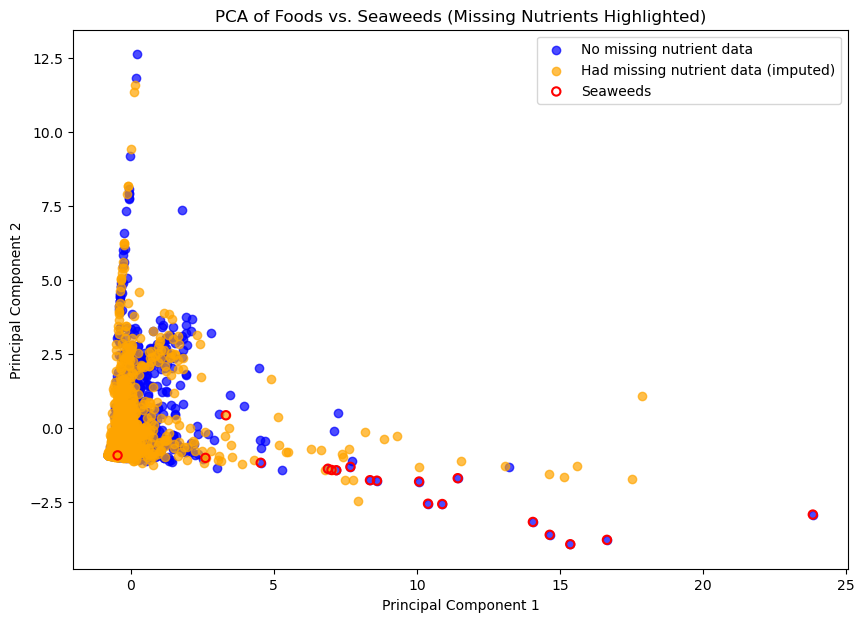

In [51]:

plt.figure(figsize=(10, 7))

# Foods with no missing data
plt.scatter(
    pca_df.loc[~pca_df['has_missing'], 'PC1'],
    pca_df.loc[~pca_df['has_missing'], 'PC2'],
    c='blue', label='No missing nutrient data', alpha=0.7
)

# Foods with missing data (imputed)
plt.scatter(
    pca_df.loc[pca_df['has_missing'], 'PC1'],
    pca_df.loc[pca_df['has_missing'], 'PC2'],
    c='orange', label='Had missing nutrient data (imputed)', alpha=0.7
)

# Highlight seaweeds
plt.scatter(
    pca_df.loc[pca_df['seaweed_group'], 'PC1'],
    pca_df.loc[pca_df['seaweed_group'], 'PC2'],
    edgecolor='red', facecolor='none', linewidth=1.5,
    label='Seaweeds'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.title("PCA of Foods vs. Seaweeds (Missing Nutrients Highlighted)")
plt.show()